In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml

import pickle
import joblib

In [ ]:
# The git clone command was failing, so we'll directly download the required file.

In [ ]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mall_customers.csv"

df = pd.read_csv("https://raw.githubusercontent.com/chowdhurymohammadtushar-sudo/k-means-clustering/main/customer_data.csv")

df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,22,15,39
1,25,20,81
2,30,45,50
3,35,60,40
4,40,80,20


In [ ]:
X = df[['Age','Annual Income (k$)','Spending Score (1-100)']]

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

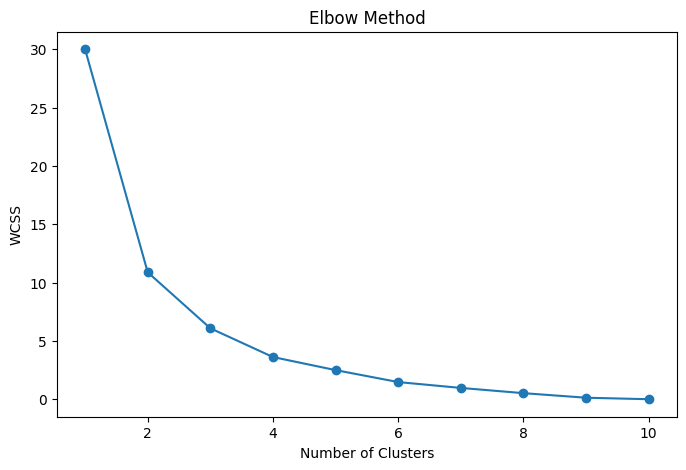

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [ ]:
df['Cluster'] = kmeans.labels_

df.head()

,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,22,15,39,3
1,25,20,81,2
2,30,45,50,0
3,35,60,40,0
4,40,80,20,1


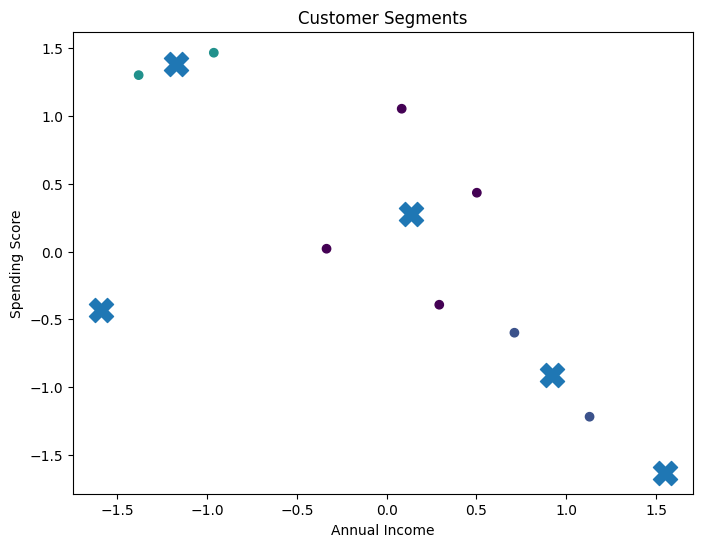

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,1],
    X_scaled[:,2],
    c=kmeans.labels_
)

plt.scatter(
    kmeans.cluster_centers_[:,1],
    kmeans.cluster_centers_[:,2],
    s=300,
    marker='X'
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.title("Customer Segments")

plt.show()

In [30]:
import os


if not os.path.exists('model'):
    os.makedirs('model')

joblib.dump(
    kmeans,
    "model/kmeans_model.pkl"
)

joblib.dump(
    scaler,
    "model/scaler.pkl"
)

['model/scaler.pkl']

In [31]:
custom_df = pd.read_csv(
    "https://raw.githubusercontent.com/chowdhurymohammadtushar-sudo/k-means-clustering/main/customer_data.csv"
)

In [32]:
scaler = joblib.load(
    "model/scaler.pkl"
)

custom_scaled = scaler.transform(custom_df)

In [33]:
model = joblib.load(
    "model/kmeans_model.pkl"
)

custom_df['Cluster'] = model.predict(custom_scaled)

custom_df

,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,22,15,39,3
1,25,20,81,2
2,30,45,50,0
3,35,60,40,0
4,40,80,20,1
5,28,55,75,0
6,50,90,10,4
7,45,70,35,1
8,27,30,85,2
9,33,65,60,0


In [34]:
print(custom_df)

   Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0   22                  15                      39        3
1   25                  20                      81        2
2   30                  45                      50        0
3   35                  60                      40        0
4   40                  80                      20        1
5   28                  55                      75        0
6   50                  90                      10        4
7   45                  70                      35        1
8   27                  30                      85        2
9   33                  65                      60        0
